In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import chromadb

In [3]:
df = pd.read_csv('../data/calories.csv')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   FoodCategory      2225 non-null   object
 1   FoodItem          2225 non-null   object
 2   per100grams       2225 non-null   object
 3   Cals_per100grams  2225 non-null   object
 4   KJ_per100grams    2225 non-null   object
dtypes: object(5)
memory usage: 87.0+ KB


,FoodCategory,FoodItem,per100grams,Cals_per100grams,KJ_per100grams
count,2225,2225,2225,2225,2225
unique,44,1993,2,524,524
top,BakingIngredients,Roast Beef,100g,100 cal,420 kJ
freq,95,4,1802,26,26


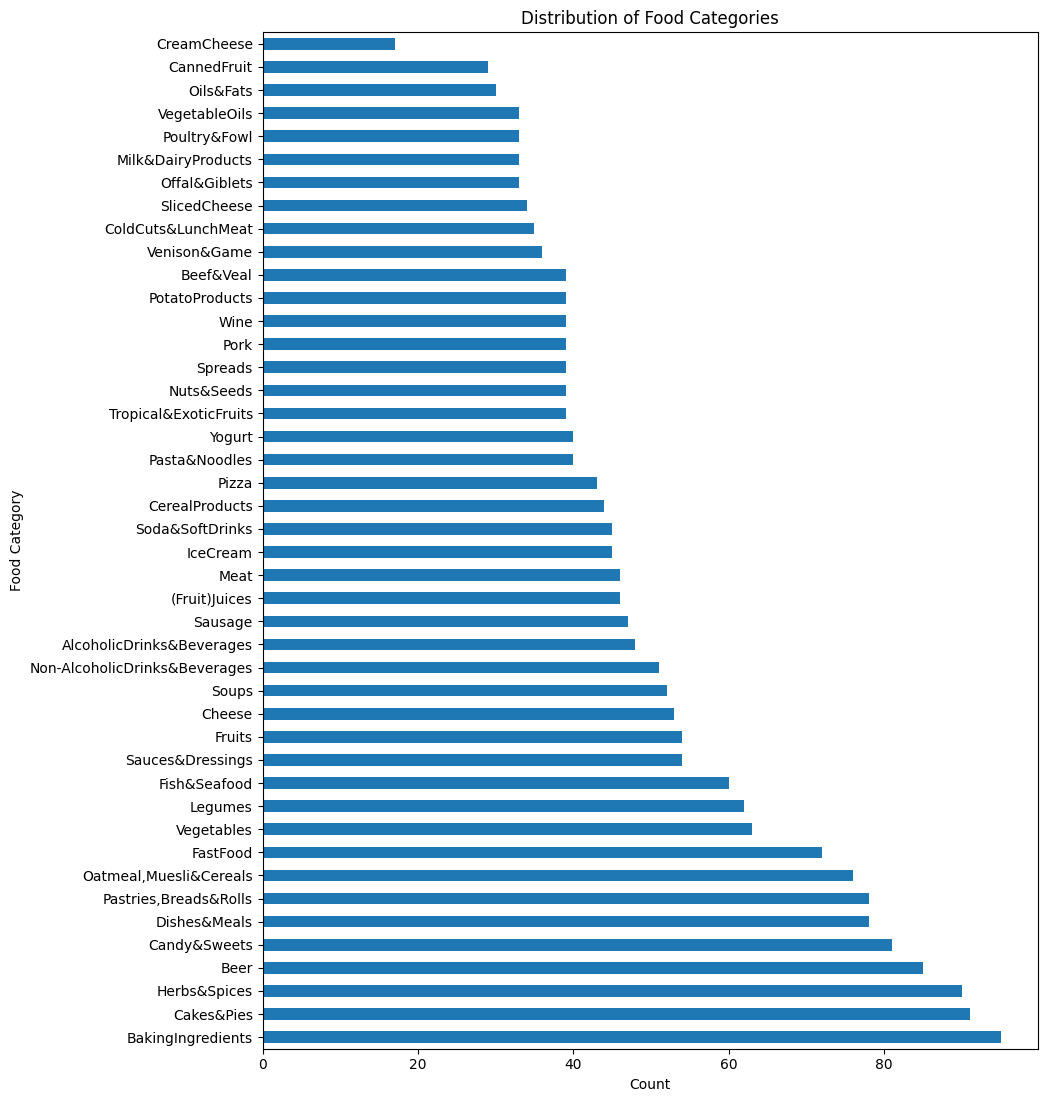

In [4]:
count_categories = df['FoodCategory'].value_counts()
plt.figure(figsize=(10, len(count_categories)*0.3))
count_categories.plot(kind='barh')
plt.title('Distribution of Food Categories')
plt.xlabel('Count')
plt.ylabel('Food Category')
plt.show()

In [5]:
# Preprocessing data
def create_chunks(csv_path: str) -> dict:
    """
    Convert csv data into ChromaDB-ready chunks.
    Each food item is a chunk
    """
    
    df = pd.read_csv(csv_path)

    docs = []
    metadatas = []
    ids = []

    for id, row in df.iterrows():
        row['Cals_per100grams'] = row['Cals_per100grams'].replace(' cal', '')
        row['KJ_per100grams'] = row['KJ_per100grams'].replace(' kJ', '')
        text = f"""
        Food: {row['FoodItem']}
        Category: {row['FoodCategory']}
        Nutritional Info:
        - Calories: {row['Cals_per100grams']} calories per 100g
        - Energy: {row['KJ_per100grams']} KJ per 100g
        - Serving size reference: {row['per100grams']}
        This is a {row['FoodItem'].lower()} food item that provides {row['Cals_per100grams']} calories per 100 grams.
        """

        metadata = {
            "food_item": row['FoodItem'],
            "food_category": row['FoodCategory'],
            "calories_per_100g": (
                row['Cals_per100grams'] if pd.notna(row['Cals_per100grams']) else 0
            ),
            "energy_per_100g": (
                row['KJ_per100grams'] if pd.notna(row['KJ_per100grams']) else 0 
            ),
            "serving_info": row['per100grams'],
            "keywords": f"{row['FoodItem'].lower()} {row['FoodCategory'].lower()}".replace(' ', '_')
        }

        docs.append(text)
        metadatas.append(metadata)
        ids.append(f"food_{id}")

    return {"documents": docs, "metadatas": metadatas, "ids": ids}

csv_path = '../data/calories.csv'
chunks = create_chunks(csv_path)
print(f"Chunks len: {len(chunks['documents'])}")
print(f"Chunk 0_doc: {chunks['documents'][0]}")
print(f"Chunk 0_metadata: {chunks['metadatas'][0]}")

Chunks len: 2225
Chunk 0_doc: 
        Food: Applesauce
        Category: CannedFruit
        Nutritional Info:
        - Calories: 62 calories per 100g
        - Energy: 260 KJ per 100g
        - Serving size reference: 100g
        This is a applesauce food item that provides 62 calories per 100 grams.
        
Chunk 0_metadata: {'food_item': 'Applesauce', 'food_category': 'CannedFruit', 'calories_per_100g': '62', 'energy_per_100g': '260', 'serving_info': '100g', 'keywords': 'applesauce_cannedfruit'}


In [6]:
# Build database using ChromaDB
def build_database(chunks: dict, collection_name: str = "nutrition_db"):
    """
    Create a ChromaDB collection and add the provided chunks to it.
    """
    # Initialize ChromaDB client
    client = chromadb.PersistentClient(path="../chroma")

    # Delete existing collection
    try:
        client.delete_collection(name=collection_name)
    except:
        pass

    # Create a new collection
    collection = client.create_collection(name=collection_name)

    # Add data to the collection
    collection.add(
        documents=chunks["documents"],
        metadatas=chunks["metadatas"],
        ids=chunks["ids"]
    )

    print(f"Added {len(chunks['ids'])} items to the '{collection_name}' collection.")

    return collection

collection = build_database(chunks, "nutrition_db")

Added 2225 items to the 'nutrition_db' collection.


In [7]:
# Query the collection
chroma_client = chromadb.PersistentClient(path="../chroma")
# Get collection list
collection_name = chroma_client.list_collections() #=> [Collection(name=nutrition_db)]
chroma_collection = chroma_client.get_collection(name=collection_name[0].name)

results = chroma_collection.query(
    query_texts=["apple"],
    n_results=2
)

for i, doc in enumerate(results['documents'][0]):
    print(f"\n===== Result {i+1} =====")
    print(doc)
    print(results['metadatas'][0][i])
results


===== Result 1 =====

        Food: Apple
        Category: Fruits
        Nutritional Info:
        - Calories: 52 calories per 100g
        - Energy: 218 KJ per 100g
        - Serving size reference: 100g
        This is a apple food item that provides 52 calories per 100 grams.
        
{'keywords': 'apple_fruits', 'energy_per_100g': '218', 'serving_info': '100g', 'food_category': 'Fruits', 'calories_per_100g': '52', 'food_item': 'Apple'}

===== Result 2 =====

        Food: Apple Spritzer
        Category: Non-AlcoholicDrinks&Beverages
        Nutritional Info:
        - Calories: 24 calories per 100g
        - Energy: 101 KJ per 100g
        - Serving size reference: 100ml
        This is a apple spritzer food item that provides 24 calories per 100 grams.
        
{'energy_per_100g': '101', 'keywords': 'apple_spritzer_non-alcoholicdrinks&beverages', 'food_category': 'Non-AlcoholicDrinks&Beverages', 'food_item': 'Apple Spritzer', 'calories_per_100g': '24', 'serving_info': '100ml'}

{'ids': [['food_30', 'food_1221']],
 'embeddings': None,
 'documents': [['\n        Food: Apple\n        Category: Fruits\n        Nutritional Info:\n        - Calories: 52 calories per 100g\n        - Energy: 218 KJ per 100g\n        - Serving size reference: 100g\n        This is a apple food item that provides 52 calories per 100 grams.\n        ',
   '\n        Food: Apple Spritzer\n        Category: Non-AlcoholicDrinks&Beverages\n        Nutritional Info:\n        - Calories: 24 calories per 100g\n        - Energy: 101 KJ per 100g\n        - Serving size reference: 100ml\n        This is a apple spritzer food item that provides 24 calories per 100 grams.\n        ']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'keywords': 'apple_fruits',
    'energy_per_100g': '218',
    'serving_info': '100g',
    'food_category': 'Fruits',
    'calories_per_100g': '52',
    'food_item': 'Apple'},
   {'energy_per_100g': '101',
    'keyword